<a href="https://colab.research.google.com/github/OgunbanjoT/Lab2AI/blob/main/AI_Assignment6_Toyin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# --- Imports ---
# TODO: Import all the necessary libraries for data handling, visualization, and model building.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
# --- Data Collection and Loading ---
# TODO: Load the 'California Housing' dataset from sklearn and convert it into a pandas DataFrame.
california = fetch_california_housing(as_frame=True)
df = california.frame

In [4]:
# --- Quick Check of Data ---
# TODO: Display the first few rows of the dataset to understand its structure.
print("--- First 5 Rows of the Dataset ---")
print(df.head())
print("\n" + "="*50 + "\n")

--- First 5 Rows of the Dataset ---
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  




In [5]:
# TODO: Check the features and target variable. Identify which is continuous and categorical if applicable.
print("--- Dataset Information (Data Types and Null Checks) ---")
print(df.info())
print("\n" + "="*50 + "\n")

--- Dataset Information (Data Types and Null Checks) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None




In [6]:
print("--- Statistical Summary ---")
print(df.describe())
print("\n" + "="*50 + "\n")
# Note: All features and the target variable (MedHouseVal) are continuous numerical values.

--- Statistical Summary ---
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude   MedHouseVal  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532      1.153956  
min 

In [7]:
# --- EDA and Data Preprocessing ---
# TODO: Check for missing/null values.
print("--- Missing/Null Values Count ---")
print(df.isnull().sum())
print("\n" + "="*50 + "\n")

--- Missing/Null Values Count ---
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64




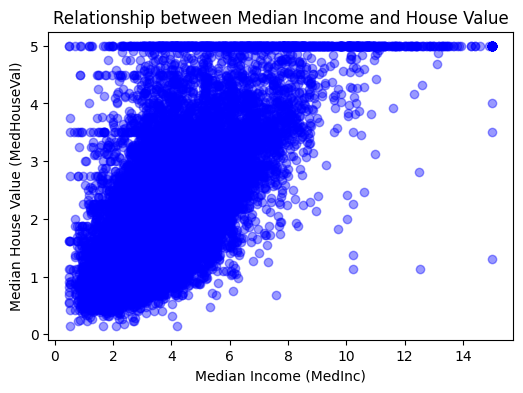

In [8]:
# TODO: Visualize the data. Create scatter plots to see the relationship between independent features and the target variable (MedHouseVal).
plt.figure(figsize=(6, 4))
plt.scatter(df['MedInc'], df['MedHouseVal'], alpha=0.4, color='b')
plt.xlabel('Median Income (MedInc)')
plt.ylabel('Median House Value (MedHouseVal)')
plt.title('Relationship between Median Income and House Value')
plt.show()

In [10]:
# TODO: Create a function to automate scatter plots for all features vs MedHouseVal.
def plot_scatter(features, target, dataframe):
    """
    Automates generating scatter plots for a list of features against a target variable.
    """
    for feature in features:
        plt.figure(figsize=(6, 4))
        plt.scatter(dataframe[feature], dataframe[target], alpha=0.3, color='crimson')
        plt.xlabel(feature)
        plt.ylabel(target)
        plt.title(f'Scatter Plot: {feature} vs {target}')
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.show()

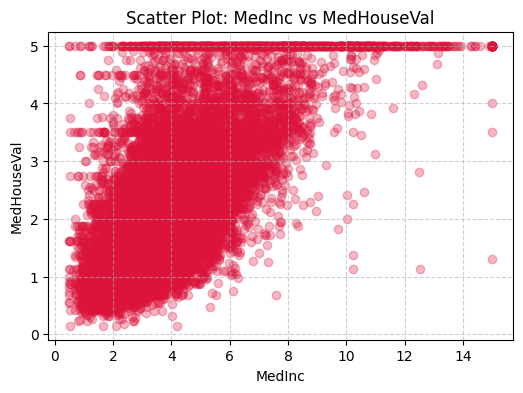

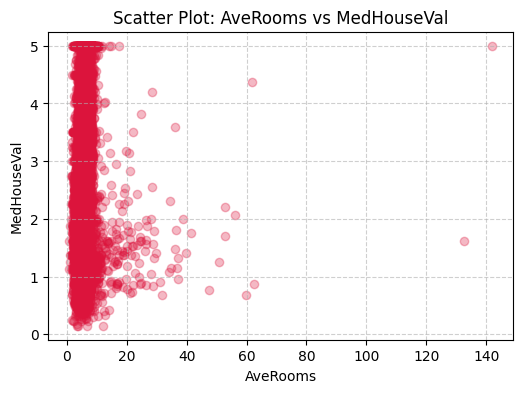

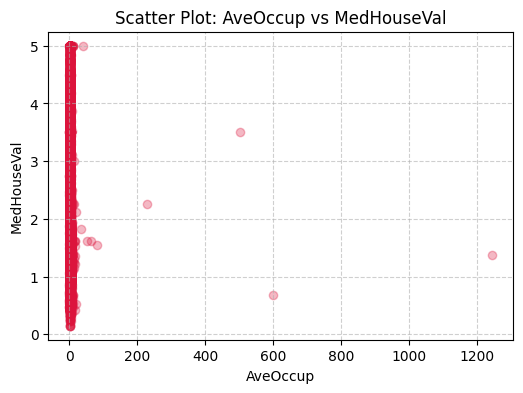

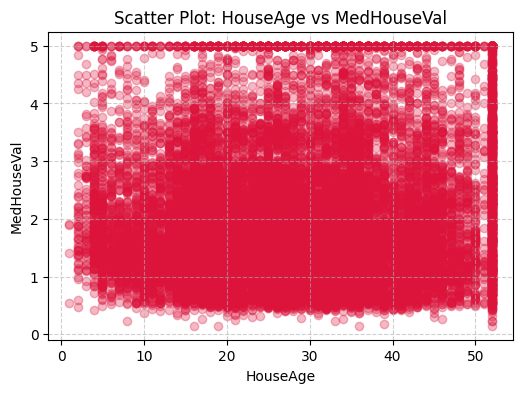

In [11]:
# TODO: Use the function to visualize the relationships between multiple features and the target variable.
features_to_plot = ['MedInc', 'AveRooms', 'AveOccup', 'HouseAge']
plot_scatter(features=features_to_plot, target='MedHouseVal', dataframe=df)

In [12]:
# --- ML Model Training ---
# TODO: Split the dataset into training and testing sets (80/20 split).
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
# TODO: Choose an appropriate regression model.
model = LinearRegression()

In [14]:
# TODO: Train the model on the training data.
model.fit(X_train, y_train)
print("Model training complete.")
print("\n" + "="*50 + "\n")

Model training complete.




In [15]:
# --- Model Evaluation ---
# TODO: Evaluate the performance of the model on the test set using relevant metrics (e.g., RMSE, R-squared).
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("--- Model Evaluation Metrics ---")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2) Score: {r2:.4f}")
print("\n" + "="*50 + "\n")

--- Model Evaluation Metrics ---
Root Mean Squared Error (RMSE): 0.7456
R-squared (R2) Score: 0.5758




In [16]:
# --- Model Prediction ---
# TODO: Predict Median House Value from a new set of feature inputs.
# Example data order must match X columns: MedInc, HouseAge, AveRooms, AveBedrms, Population, AveOccup, Latitude, Longitude
new_sample = pd.DataFrame([{
    'MedInc': 3.0,
    'HouseAge': 30.0,
    'AveRooms': 6.0,
    'AveBedrms': 1.0,
    'Population': 1500.0,
    'AveOccup': 3.0,
    'Latitude': 34.0,
    'Longitude': -118.0
}])

# Ensure columns align perfectly with training features
new_sample = new_sample[X.columns]

predicted_value = model.predict(new_sample)
print("--- New Data Prediction ---")
print(f"Predicted Median House Value for the new input: ${predicted_value[0] * 100000:.2f} (Value key scale: {predicted_value[0]:.4f})")

--- New Data Prediction ---
Predicted Median House Value for the new input: $154866.33 (Value key scale: 1.5487)
